In [1]:
# conection to google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# unziping dataset
!unzip /content/drive/MyDrive/data/Animals-10.zip -d /content/dataset

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/raw-img/ragno/OIP-MVQChNQpHiMZEVMPehrvoAHaE6.jpeg  
  inflating: /content/dataset/raw-img/ragno/OIP-MVdIFDAFpNyK_XCpwkDIWgHaFj.jpeg  
  inflating: /content/dataset/raw-img/ragno/OIP-MYY_8k5AHqMJwTCNXfH6rwHaFj.jpeg  
  inflating: /content/dataset/raw-img/ragno/OIP-MZEVXuoMsATG8u_UuTQ6hAHaE8.jpeg  
  inflating: /content/dataset/raw-img/ragno/OIP-MZg0tznDRE95AMfyuutuYAHaE6.jpeg  
  inflating: /content/dataset/raw-img/ragno/OIP-M_r9DkR2X5gP0P5-z8wPYQHaE7.jpeg  
  inflating: /content/dataset/raw-img/ragno/OIP-M_xDUSzjlF3-w9XHCm93cgHaFF.jpeg  
  inflating: /content/dataset/raw-img/ragno/OIP-MbI4-bMyutRX3X382IAVcQAAAA.jpeg  
  inflating: /content/dataset/raw-img/ragno/OIP-MbMksZdD7gomsC9fd6cpKgHaHJ.jpeg  
  inflating: /content/dataset/raw-img/ragno/OIP-Md4AMcvjaHcivJqeW06wEwHaFW.jpeg  
  inflating: /content/dataset/raw-img/ragno/OIP-MgCgailkT5XkO1XczzQCngHaLK.jpeg  
  inflating: /content/dataset/raw-img/ragno/OIP

In [3]:
# imports
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import os
from PIL import Image
from collections import Counter

import torch
from torch import optim
import torchvision
from torchvision import models
import torchvision.datasets
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision.utils import make_grid
from torchvision.io import read_image

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix

# **init resnet model**

In [4]:
model = models.resnet50(pretrained=True)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 184MB/s]


# **2. Налаштування кількості вихідних класів**

# **loading data**

In [5]:
# counting number of images in classes
path = '/content/dataset/raw-img'
classes = os.listdir(path)

class_names = {}
for class_name in classes:
  class_names[class_name] = len(os.listdir(os.path.join(path, class_name)))

class_names

{'cavallo': 2623,
 'ragno': 4821,
 'mucca': 1866,
 'cane': 4863,
 'scoiattolo': 1862,
 'elefante': 1446,
 'gallina': 3098,
 'gatto': 1668,
 'farfalla': 2112,
 'pecora': 1820}

In [6]:
# loading dataset
data = torchvision.datasets.ImageFolder(root='/content/dataset/raw-img', transform=None)

In [7]:
# getting classes names
classes = data.classes
num_classes = len(classes)
print(f'data classes: {classes}, number of classes: {num_classes}')

data classes: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo'], number of classes: 10


In [8]:
model.fc = nn.Linear(model.fc.in_features, num_classes)

In [9]:
model.fc

Linear(in_features=2048, out_features=10, bias=True)

In [10]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

# **3. Проведення донавчання моделі**

In [11]:
layers = ['layer4', 'layer3', 'layer2', 'layer1']

In [13]:
def unfreeze_layer(model, layer):
    for name, param in model.named_parameters():
        if layer in name:
            param.requires_grad = True

In [14]:
for param in model.parameters():
    param.requires_grad = False

# unfreezing of layer 4 (first)
for param in model.layer4.parameters():
    param.requires_grad = True

In [15]:
learning_rate = 1e-4

In [17]:
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=10, threshold=0.0001, threshold_mode='abs')

In [18]:
IMAGE_SIZE = (224, 224)
MEANS = [0.517645001411438, 0.5002366304397583, 0.4124912917613983]
STDS = [0.2544998228549957, 0.2494899481534958, 0.2677474021911621]

In [21]:
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE[0]),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEANS, std=STDS)
])

In [22]:
transform_test = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEANS, std=STDS)
])

In [23]:
# transtating classes to english
translate = {"cane": "dog", "cavallo": "horse", "elefante": "elephant", "farfalla": "butterfly", "gallina": "chicken", "gatto": "cat", "mucca": "cow",
             "pecora": "sheep", "ragno": "spider", "scoiattolo": "squirrel"}
classes_eng = [translate[animal] for animal in translate]

# **dividing dataset to train and test**

In [24]:
# dividing dataset to train, validation and test
train_size = int(len(data) * 0.6)
test_size = int(len(data) * 0.2)
val_size = int(len(data) - train_size - test_size)

train_data, test_data, valid_data = random_split(dataset=data, lengths=[train_size, test_size, val_size])
print(f'train: {len(train_data):<20} test: {len(test_data):<20} validation: {len(valid_data)}')

train: 15707                test: 5235                 validation: 5237


## **adding transformation to datasets**

In [25]:
class SubsetWithTransform():
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        image, label = self.subset[index]
        if self.transform:
            image = self.transform(image)
        return image, label

    def __len__(self):
        return len(self.subset)

In [26]:
train_data = SubsetWithTransform(train_data, transform=train_transforms)
test_data = SubsetWithTransform(test_data, transform=transform_test)
valid_data = SubsetWithTransform(valid_data, transform=train_transforms)

In [27]:
train_data.transform, test_data.transform, valid_data.transform

(Compose(
     RandomResizedCrop(size=(224, 224), scale=(0.08, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
     RandomHorizontalFlip(p=0.5)
     RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
     ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=None)
     ToTensor()
     Normalize(mean=[0.517645001411438, 0.5002366304397583, 0.4124912917613983], std=[0.2544998228549957, 0.2494899481534958, 0.2677474021911621])
 ),
 Compose(
     Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
     ToTensor()
     Normalize(mean=[0.517645001411438, 0.5002366304397583, 0.4124912917613983], std=[0.2544998228549957, 0.2494899481534958, 0.2677474021911621])
 ),
 Compose(
     RandomResizedCrop(size=(224, 224), scale=(0.08, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
     RandomHorizontalFlip(p=0.5)
     RandomRotation(degrees=[-15.0, 15.0], interpolation=neare

## **creating data loaders**

In [28]:
num_workers = 2

In [29]:
batch_size=32
batch_size

32

In [30]:
# creating data loader
data_loader = DataLoader(dataset=data, batch_size=batch_size, shuffle=True, num_workers=num_workers)
data_loader

In [31]:
# creating data loader for test and train data
train_loader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True, num_workers=num_workers)
test_loader = DataLoader(dataset=test_data, batch_size=batch_size, shuffle=False, num_workers=num_workers)

In [32]:
# creating data loader for validation data
valid_loader = DataLoader(dataset=valid_data, batch_size=batch_size, shuffle=False, num_workers=num_workers)

In [33]:
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [34]:
loss_function = nn.CrossEntropyLoss()

In [43]:
number_epochs = 20
number_epochs

20

In [44]:
len(valid_data), valid_loader.batch_size

(5237, 32)

In [45]:
print(f'Model: {model},\n\nLoss function: {loss_function},\n\nOptimizer: {optimizer},\n\nScheduler: {scheduler}')

Model: ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stri

In [46]:
def evaluate_metrics(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
    precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    return accuracy * 100, precision, recall, f1

In [47]:
train_loss_list = []
val_loss_list = []
train_metrics = {metric: [] for metric in ['accuracy', 'f1_score', 'recall_score', 'precision']}
val_metrics = {metric: [] for metric in ['accuracy', 'f1_score', 'recall_score', 'precision']}

In [48]:
def train_epoch():
  model.train()
  train_loss = torch.tensor(0.0, device=device)

  for images, labels in train_loader:
      images, labels = images.to(device), labels.to(device)
      optimizer.zero_grad()
      outputs = model(images)
      loss = loss_function(outputs, labels)
      loss.backward()
      optimizer.step()
      train_loss += loss.item()

  train_loss = train_loss.item() / len(train_loader)
  train_loss_list.append(train_loss)

  train_accuracy, train_precision, train_recall, train_f1 = evaluate_metrics(model, train_loader)
  train_metrics['accuracy'].append(train_accuracy)
  train_metrics['f1_score'].append(train_f1)
  train_metrics['recall_score'].append(train_recall)
  train_metrics['precision'].append(train_precision)
  return train_loss, train_accuracy, train_precision, train_recall, train_f1

In [49]:
def eval_epoch():
  model.eval()
  val_loss = torch.tensor(0.0, device=device)

  with torch.no_grad():
      for images, labels in valid_loader:
          images, labels = images.to(device), labels.to(device)
          outputs = model(images)
          loss = loss_function(outputs, labels)
          val_loss += loss.item()

  val_loss = val_loss.item() / len(valid_loader)
  val_loss_list.append(val_loss)

  val_accuracy, val_precision, val_recall, val_f1 = evaluate_metrics(model, valid_loader)
  val_metrics['accuracy'].append(val_accuracy)
  val_metrics['f1_score'].append(val_f1)
  val_metrics['recall_score'].append(val_recall)
  val_metrics['precision'].append(val_precision)
  return val_loss, val_accuracy, val_precision, val_recall, val_f1

In [51]:
for epoch in range(number_epochs):

    if epoch == 5:
        unfreeze_layer(model, layers[1])
    elif epoch == 10:
        unfreeze_layer(model, layers[2])
    elif epoch == 15:
        unfreeze_layer(model, layers[-1])

    train_loss, train_accuracy, train_precision, train_recall, train_f1 = train_epoch()
    val_loss, val_accuracy, val_precision, val_recall, val_f1 = eval_epoch()
    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}/{number_epochs}:"
          f"\n\tTrain Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%,"
          f"\n\tTrain Precision: {train_precision:.4f}, Train Recall: {train_recall:.4f}, Train F1-score: {train_f1:.4f}"
          f"\n\tVal Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%,"
          f"\n\tVal Precision: {val_precision:.4f}, Val Recall: {val_recall:.4f}, Val F1-score: {val_f1:.4f}\n")

Epoch 1/20:
	Train Loss: 0.3089, Train Accuracy: 92.89%,
	Train Precision: 0.9214, Train Recall: 0.9256, Train F1-score: 0.9234
	Val Loss: 0.2483, Validation Accuracy: 91.04%,
	Val Precision: 0.8989, Val Recall: 0.9079, Val F1-score: 0.9031

Epoch 2/20:
	Train Loss: 0.2723, Train Accuracy: 92.61%,
	Train Precision: 0.9285, Train Recall: 0.9178, Train F1-score: 0.9223
	Val Loss: 0.2589, Validation Accuracy: 91.56%,
	Val Precision: 0.9212, Val Recall: 0.9064, Val F1-score: 0.9123

Epoch 3/20:
	Train Loss: 0.2564, Train Accuracy: 93.07%,
	Train Precision: 0.9307, Train Recall: 0.9236, Train F1-score: 0.9269
	Val Loss: 0.2699, Validation Accuracy: 90.97%,
	Val Precision: 0.9065, Val Recall: 0.9004, Val F1-score: 0.9028

Epoch 4/20:
	Train Loss: 0.2616, Train Accuracy: 93.95%,
	Train Precision: 0.9324, Train Recall: 0.9347, Train F1-score: 0.9332
	Val Loss: 0.2372, Validation Accuracy: 92.36%,
	Val Precision: 0.9174, Val Recall: 0.9188, Val F1-score: 0.9179

Epoch 5/20:
	Train Loss: 0.2479,

Text(0.5, 1.0, 'Train Recall Score')

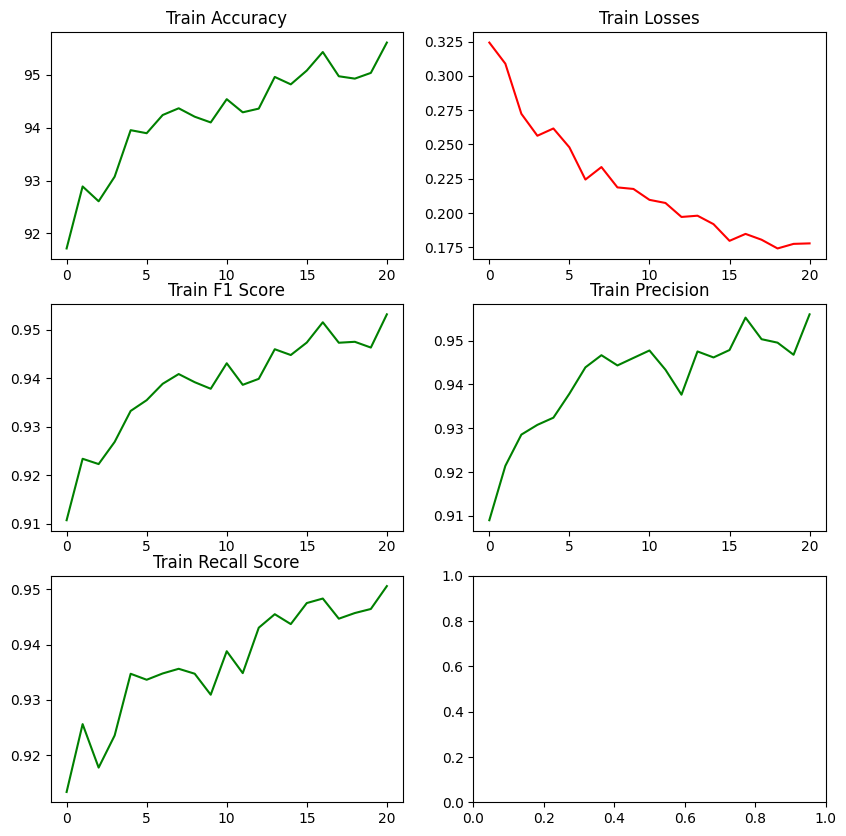

In [52]:
fig, ax = plt.subplots(3, 2, figsize=(10, 10))

ax[0,0].plot(train_metrics['accuracy'], color='g')
ax[0,0].set_title('Train Accuracy')

ax[0,1].plot(train_loss_list, color='r')
ax[0,1].set_title('Train Losses')

ax[1,0].plot(train_metrics['f1_score'], color='g')
ax[1,0].set_title('Train F1 Score')

ax[1,1].plot(train_metrics['precision'], color='g')
ax[1,1].set_title('Train Precision')

ax[2,0].plot(train_metrics['recall_score'], color='g')
ax[2,0].set_title('Train Recall Score')

Text(0.5, 1.0, 'Validation Recall Score')

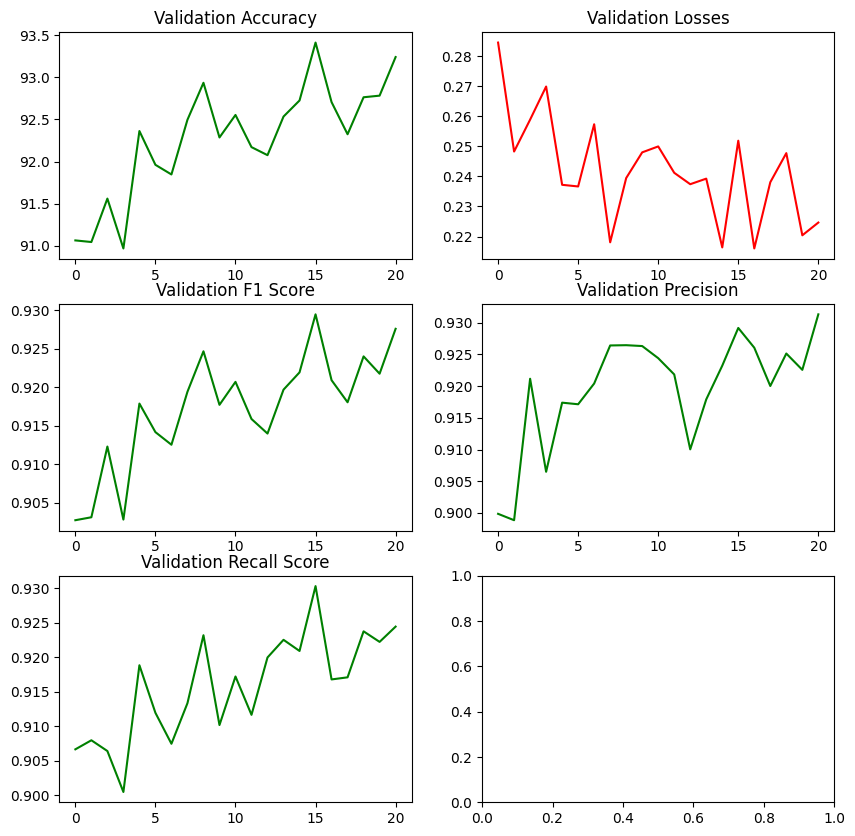

In [54]:
fig, ax = plt.subplots(3, 2, figsize=(10, 10))

ax[0,0].plot(val_metrics['accuracy'], color='g')
ax[0,0].set_title('Validation Accuracy')

ax[0,1].plot(val_loss_list, color='r')
ax[0,1].set_title('Validation Losses')

ax[1,0].plot(val_metrics['f1_score'], color='g')
ax[1,0].set_title('Validation F1 Score')

ax[1,1].plot(val_metrics['precision'], color='g')
ax[1,1].set_title('Validation Precision')

ax[2,0].plot(val_metrics['recall_score'], color='g')
ax[2,0].set_title('Validation Recall Score')

In [55]:
all_labels = []
all_preds = []
all_images = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)

        all_labels.append(labels.cpu().numpy())
        all_preds.append(predicted.cpu().numpy())
        all_images.append(images.cpu().numpy())

all_labels = np.concatenate(all_labels)
all_preds = np.concatenate(all_preds)
all_images = np.concatenate(all_images)

In [56]:
incorrect_indices = np.where(all_labels != all_preds)[0]
incorrect_images = all_images[incorrect_indices]
incorrect_labels = all_labels[incorrect_indices]
incorrect_preds = all_preds[incorrect_indices]

In [66]:
len(incorrect_indices), len(all_labels), len(incorrect_labels) / len(all_labels) * 100

(167, 5235, 3.1900668576886346)

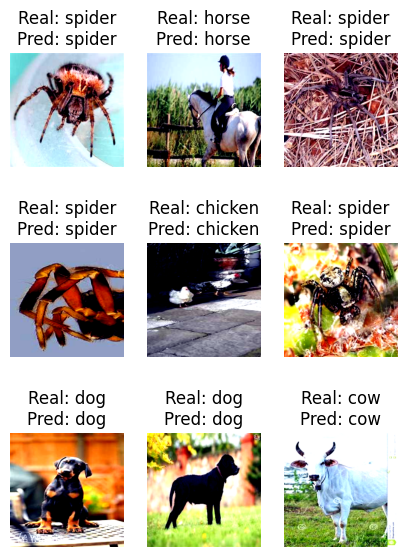

In [58]:
fig, axes = plt.subplots(3, 3, figsize=(5, 7))
model.eval()

images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)
outputs = model(images)
_, predicted = outputs.max(1)

for i, ax in enumerate(axes.flat):
    img = images[i]
    img = img / 2 + 0.5
    img = img.cpu().numpy().transpose((1, 2, 0))
    ax.imshow(img)
    ax.set_title(f'Real: {classes_eng[labels[i].item()]}\nPred: {classes_eng[predicted[i].item()]}')
    ax.axis('off')
plt.show()

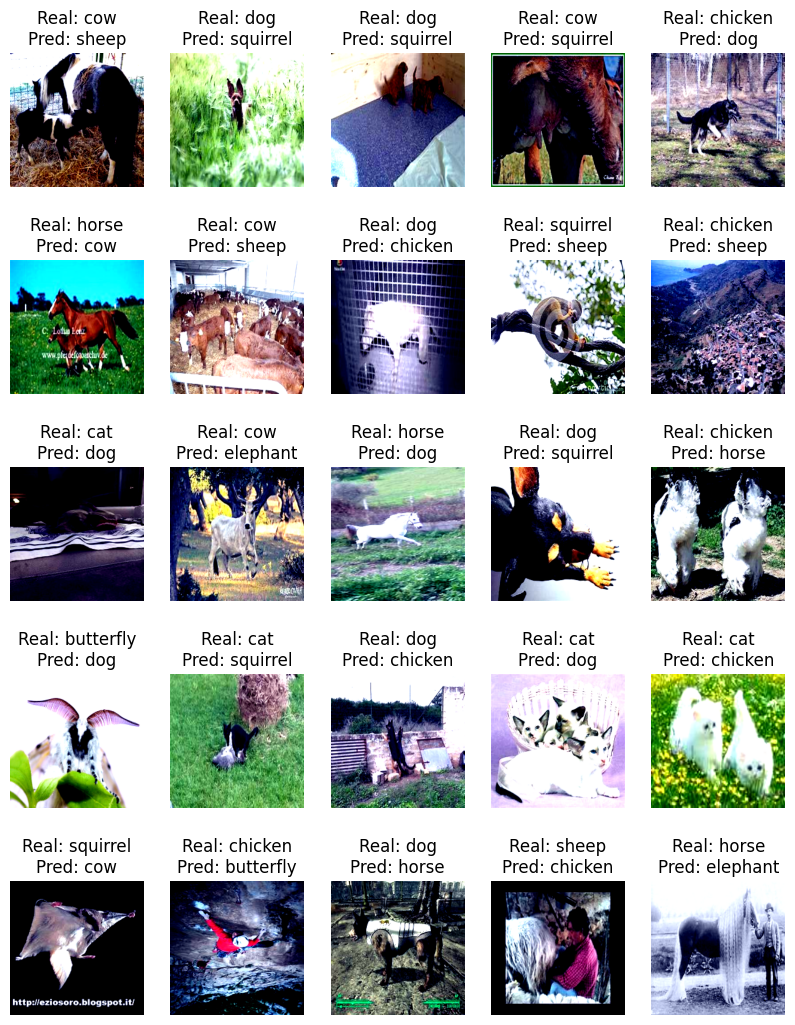

In [59]:
fig, axes = plt.subplots(5, 5, figsize=(10, 13))

for i, ax in enumerate(axes.flat):
    if i < len(incorrect_images):
        img = incorrect_images[i]
        img = img.transpose((1, 2, 0))
        img = (img * 0.5) + 0.5

        ax.imshow(img)
        ax.set_title(f'Real: {classes_eng[incorrect_labels[i]]}\nPred: {classes_eng[incorrect_preds[i]]}')
        ax.axis('off')
    else:
        ax.axis('off')

plt.show()

Більшість неправильних передбачень були зроблені для фотографій на яких не зрозуміло, що зображене навіть на людський погляд. А також в датасеті наявні зображення, де взагалі немає тварин, але вони розмічені, наприклад в останньому ряді 2 фото: на ньому зображена людина, а аж ніяк не курка чи корова, як передбачила модель.

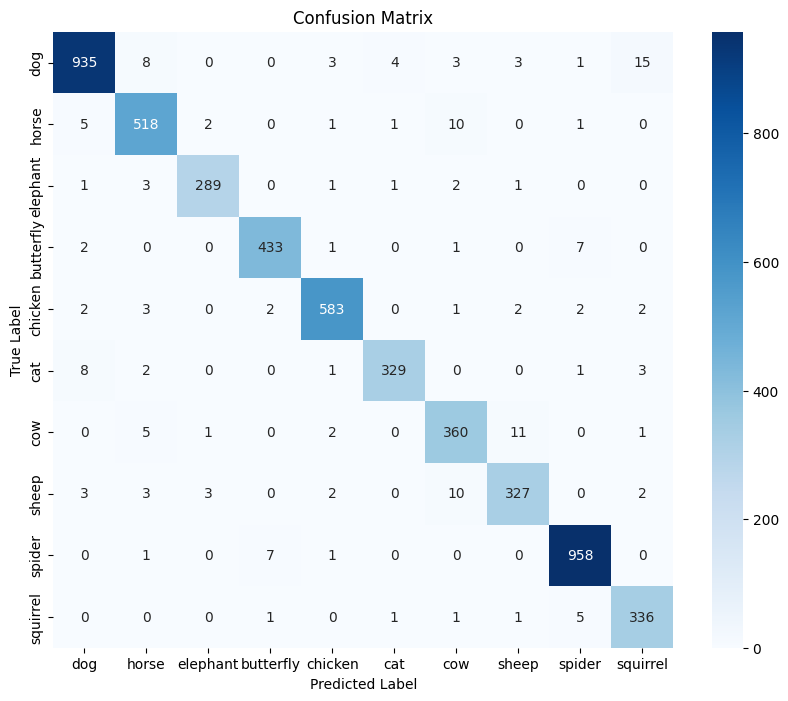

In [68]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes_eng, yticklabels=classes_eng)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

Найкраще передбачення були зроблені на класах "Павук" та "Собака", можливо це зумовлено найбільшою часткою зображень даних класів в датасеті. Найгірші передбачення класу "Слон", оскільки у цього класу найменше фото. Отже точність передбачень залежить від кількості екземплярів представників певного класу.

In [61]:
print(classification_report(all_labels, all_preds, target_names=classes_eng))

              precision    recall  f1-score   support

         dog       0.98      0.96      0.97       972
       horse       0.95      0.96      0.96       538
    elephant       0.98      0.97      0.97       298
   butterfly       0.98      0.98      0.98       444
     chicken       0.98      0.98      0.98       597
         cat       0.98      0.96      0.97       344
         cow       0.93      0.95      0.94       380
       sheep       0.95      0.93      0.94       350
      spider       0.98      0.99      0.99       967
    squirrel       0.94      0.97      0.95       345

    accuracy                           0.97      5235
   macro avg       0.96      0.96      0.96      5235
weighted avg       0.97      0.97      0.97      5235



Найкращі f1 score у класу 'spider' (0.99)

Найгірші - у 'horse' (0.96)

In [63]:
torch.save(model.state_dict(), 'model_best.pth')